### Supplementary Fig. 7: annotated large terminase, portal, and major capsid proteins in the top VFCs
For each VFC, protein clusters (PCs) with genes annotated as large terminase, portal protein, or major capsid protein were manually inspected, and PCs were assigned these functions (see Supplementary Data 11).

In [1]:
import pandas as pd

df_v = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','VFC'])

df_g = pd.read_csv('../data/Supplementary_Data_4_gene_annotations_of_SPMP_and_reference_vOTUs.tsv', sep='\t', usecols=['gene','large_terminase_PC','portal_PC','mcp_PC'])
df_g = df_g[df_g.gene.str.startswith('TLL')] # only the SPMP vOTUs start with 'TLL'
df_g['votu_id'] = df_g.gene.str.rsplit('_', n=1).str[0]

df_v = df_v.merge(df_g.groupby('votu_id', as_index=False)[['large_terminase_PC', 'portal_PC', 'mcp_PC']].sum(), on='votu_id', how='left')

In [2]:
df_topvfc = df_v[df_v['VFC'].between(1, 12)].copy()
df_topvfc.VFC = df_topvfc.VFC.astype(int)

percent_df = (
    df_topvfc
    .groupby('VFC', as_index=False)[['large_terminase_PC', 'portal_PC', 'mcp_PC']]
    .apply(lambda x: (x != 0).mean() * 100)
)

melted_df = percent_df.melt(
    id_vars='VFC',
    var_name='Category',
    value_name='Percentage'
)

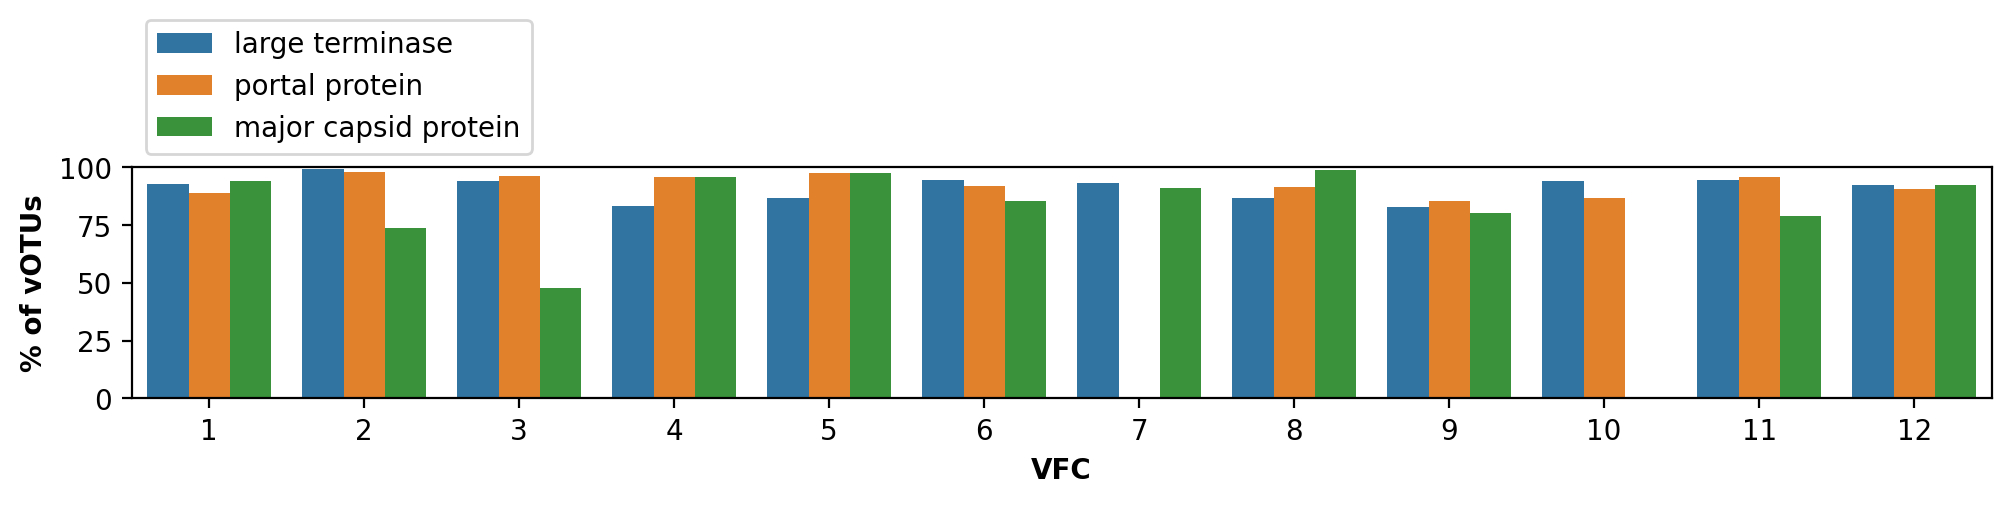

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 1.5), dpi=200)

sns.barplot(data=melted_df, x='VFC', y='Percentage', hue='Category')

plt.title('')
plt.xlabel('VFC', fontweight='bold')
plt.ylabel('% of vOTUs', fontweight='bold')
plt.ylim(0,100)

legend_handles, _ = ax.get_legend_handles_labels()
ax.legend(legend_handles, ['large terminase', 'portal protein', 'major capsid protein'], title='', loc='lower left', bbox_to_anchor=(0, 1))